# Retorno acumulado de clases de activos globalesComparacion del retorno acumulado de 10 activos que representan distintas clases(renta fija de corto y largo plazo, renta variable desarrollada y emergente,sectores defensivos e inmobiliario) durante los ultimos 12 meses.**Pregunta:** que clases de activos superaron al S&P 500 en el periodo, y quedice esa dispersion sobre el momento del ciclo.**Fuente:** Yahoo Finance via `yfinance`, precios ajustados por dividendos y splits.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Cambia esta línea en tu código
simbolos = ['VNQ', 'BIL', 'IEF', 'EWG', 'XLV', 'XLU', 'SPY','EWZ','^KS11','^NSEI']

In [ ]:
df=yf.download(simbolos, period='1y', auto_adjust=False)['Adj Close']
df

[*********************100%***********************]  10 of 10 completed


Ticker,BIL,EWG,EWZ,IEF,SPY,VNQ,XLU,XLV,^KS11,^NSEI
Date,,,,,,,,,,
2025-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2576.159912,22544.699219
2025-03-07,88.175270,38.175167,23.540876,91.168358,569.235352,88.921883,37.571777,146.699692,2563.479980,22552.500000
2025-03-10,88.184921,37.171852,23.047676,91.805832,554.073486,88.065575,37.984978,145.117523,2570.389893,22460.300781
2025-03-11,88.194542,37.122669,23.123554,91.477448,549.467468,87.036072,37.630112,143.535355,2537.600098,22497.900391
2025-03-12,88.204178,37.368580,23.218399,91.206993,552.383301,86.766678,37.513439,142.100586,2574.820068,22470.500000
...,...,...,...,...,...,...,...,...,...,...
2026-03-02,91.389999,42.910000,38.639999,97.120003,686.380005,95.930000,47.369999,158.529999,NaN,24865.699219
2026-03-03,91.400002,41.570000,36.820000,97.010002,680.330017,95.419998,47.070000,156.740005,5791.910156,NaN
2026-03-04,91.410004,42.099998,37.490002,96.809998,685.130005,95.540001,47.270000,157.050003,5093.540039,24480.500000


In [ ]:
for i in simbolos:
    # Calcula el rendimiento porcentual diario
    df['ret_diario_' + i] = df[i].pct_change()

for i in simbolos:
    # Calcula el rendimiento acumulado compuesto
    df['ret_diario_acum_' + i] = (1 + df['ret_diario_' + i]).cumprod() - 1

# Visualiza el DataFrame con las nuevas columnas
df

Ticker,BIL,EWG,EWZ,IEF,SPY,VNQ,XLU,XLV,^KS11,^NSEI,...,ret_diario_acum_VNQ,ret_diario_acum_BIL,ret_diario_acum_IEF,ret_diario_acum_EWG,ret_diario_acum_XLV,ret_diario_acum_XLU,ret_diario_acum_SPY,ret_diario_acum_EWZ,ret_diario_acum_^KS11,ret_diario_acum_^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2576.159912,22544.699219,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-07,88.175270,38.175167,23.540876,91.168358,569.235352,88.921883,37.571777,146.699692,2563.479980,22552.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004922,0.000346
2025-03-10,88.184921,37.171852,23.047676,91.805832,554.073486,88.065575,37.984978,145.117523,2570.389893,22460.300781,...,-0.009630,0.000109,0.006992,-0.026282,-0.010785,0.010998,-0.026635,-0.020951,-0.002240,-0.003744
2025-03-11,88.194542,37.122669,23.123554,91.477448,549.467468,87.036072,37.630112,143.535355,2537.600098,22497.900391,...,-0.021208,0.000219,0.003390,-0.027570,-0.021570,0.001553,-0.034727,-0.017728,-0.014968,-0.002076
2025-03-12,88.204178,37.368580,23.218399,91.206993,552.383301,86.766678,37.513439,142.100586,2574.820068,22470.500000,...,-0.024237,0.000328,0.000424,-0.021129,-0.031350,-0.001553,-0.029605,-0.013699,-0.000520,-0.003291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,91.389999,42.910000,38.639999,97.120003,686.380005,95.930000,47.369999,158.529999,NaN,24865.699219,...,0.078812,0.036458,0.065282,0.124029,0.080643,0.260787,0.205793,0.641400,1.423813,0.102951
2026-03-03,91.400002,41.570000,36.820000,97.010002,680.330017,95.419998,47.070000,156.740005,5791.910156,NaN,...,0.073077,0.036572,0.064075,0.088928,0.068441,0.252802,0.195165,0.564088,1.248273,0.102951
2026-03-04,91.410004,42.099998,37.490002,96.809998,685.130005,95.540001,47.270000,157.050003,5093.540039,24480.500000,...,0.074426,0.036685,0.061882,0.102811,0.070554,0.258125,0.203597,0.592549,0.977183,0.085865


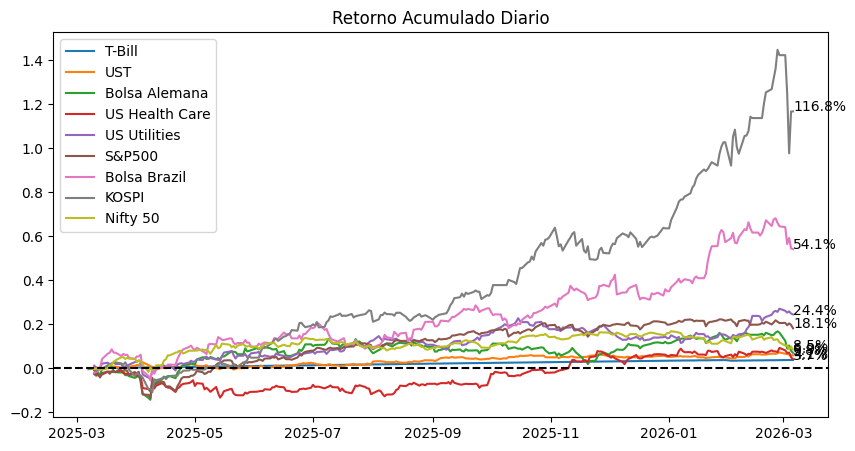

In [ ]:
plt.figure(figsize=(10,5))

# Graficando cada activo con etiquetas personalizadas
plt.plot(df.index, df['ret_diario_acum_BIL'], label='T-Bill')
# Agrega el texto del rendimiento final al final de la línea de BIL
plt.text(df.index[-1], df['ret_diario_acum_BIL'].iloc[-1], f'{df["ret_diario_acum_BIL"].iloc[-1]:.1%}')

plt.plot(df.index, df['ret_diario_acum_IEF'], label='UST')
# Agrega el texto del rendimiento final al final de la línea de IEF
plt.text(df.index[-1], df['ret_diario_acum_IEF'].iloc[-1], f'{df["ret_diario_acum_IEF"].iloc[-1]:.1%}')

plt.plot(df.index, df['ret_diario_acum_EWG'], label='Bolsa Alemana')
plt.text(df.index[-1], df['ret_diario_acum_EWG'].iloc[-1], f'{df["ret_diario_acum_EWG"].iloc[-1]:.1%}')
plt.plot(df.index, df['ret_diario_acum_XLV'], label='US Health Care')
plt.text(df.index[-1], df['ret_diario_acum_XLV'].iloc[-1], f'{df["ret_diario_acum_XLV"].iloc[-1]:.1%}')
plt.plot(df.index, df['ret_diario_acum_XLU'], label='US Utilities')
plt.text(df.index[-1], df['ret_diario_acum_XLU'].iloc[-1], f'{df["ret_diario_acum_XLU"].iloc[-1]:.1%}')
plt.plot(df.index, df['ret_diario_acum_SPY'], label='S&P500')
plt.text(df.index[-1], df['ret_diario_acum_SPY'].iloc[-1], f'{df["ret_diario_acum_SPY"].iloc[-1]:.1%}')
plt.plot(df.index, df['ret_diario_acum_EWZ'], label='Bolsa Brazil')
plt.text(df.index[-1], df['ret_diario_acum_EWZ'].iloc[-1], f'{df["ret_diario_acum_EWZ"].iloc[-1]:.1%}') #Apreciación del real, parecería más CARO
plt.plot(df.index, df['ret_diario_acum_^KS11'], label='KOSPI')
plt.text(df.index[-1], df['ret_diario_acum_^KS11'].iloc[-1], f'{df["ret_diario_acum_^KS11"].iloc[-1]:.1%}')
plt.plot(df.index, df['ret_diario_acum_^NSEI'], label='Nifty 50')
plt.text(df.index[-1], df['ret_diario_acum_^NSEI'].iloc[-1], f'{df["ret_diario_acum_^NSEI"].iloc[-1]:.1%}')
# Configuración de la gráfica
plt.legend()
plt.title('Retorno Acumulado Diario')
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

## Lectura de resultados**Debilidad sostenida del dolar.** El ETF de bolsa alemana (EWG) esta nominado endolares pero invierte en activos en euros: parte de su retorno en el periodo noproviene del desempeno del mercado aleman sino del efecto tipo de cambio. Es unrecordatorio de que en ETFs internacionales el retorno reportado mezcla dos fuentesdistintas y conviene separarlas antes de atribuir desempeno.**La inflacion cediendo hace atractiva la renta fija.** El comportamiento de IEF(bonos del Tesoro de 7 a 10 anos) frente a BIL (letras de muy corto plazo) reflejaexpectativas de recorte de tasas: cuando el mercado anticipa que las tasas bajan,la duracion larga se aprecia mas.**Los sectores defensivos arrancan lento y terminan bien.** Servicios publicos (XLU)y salud (XLV) muestran un rezago inicial frente al indice general y luego recuperan.Es el patron tipico de rotacion hacia defensivos cuando el mercado empieza adescontar desaceleracion.**Ejercicio relevante:** identificar indices que superen al SPY sin ser tecnologiani renta variable estadounidense. La dispersion observada muestra que si existen,lo que es el argumento basico a favor de la diversificacion internacional.## Limitaciones- Ventana de 12 meses: demasiado corta para conclusiones estructurales, sirve para  leer el momento del ciclo, no para estimar retornos esperados.- Los retornos estan en dolares sin cobertura cambiaria, por lo que los activos  internacionales incorporan riesgo de tipo de cambio no separado.- No se ajusta por riesgo: el grafico compara retornos, no retornos por unidad de  volatilidad.